# ADAPT-VQE Simulations

This notebook exercises the whole `ADAPT-VQE` package:

1. **Testing matrix**: every algorithm family (standard ADAPT-VQE, GGF, GGF-ADAPT),
   in both the fermionic and HCB (hard-CORE boson) encodings, for three nuclei
   spanning both the p-shell ($^6$Be, $^8$He) and the sd-shell ($^{18}$O).
   For standard ADAPT-VQE this covers the classical, quantum and mixed modes;
   GGF and GGF-ADAPT cover the classical and quantum modes.
2. **Convergence tests**: Monte Carlo shot-noise analysis of the variational
   parameters and the total energy, for both mappings.
3. **Deviation analysis**: comparison of the Z-basis reconstruction method
   against measuring each Hamiltonian term with its own circuit, and a
   bias/entropy sweep across the parameter landscape.

*Note on runtime*: the fermionic encoding of $^{18}$O uses 12 qubits with an
83-operator pool, so any cell that sweeps the full operator pool via quantum
circuits (the quantum/mixed modes of the standard ADAPT-VQE, GGF and
GGF-ADAPT algorithms) is intentionally run with small `max_layers`/
`max_executions` there — the HCB encoding of the same nucleus only needs 6
qubits and a 15-operator pool, so it stays fast.

# Fermionic Encoding

## Standard ADAPT-VQE

In [46]:
from ADAPT_VQE.Methods import ADAPT_minimization, Quantum_ADAPT_minimization, ADAPT_mixed_minimization
from ADAPT_VQE.Circuit import Circuits_Composer
from qibo import set_backend
import io
import contextlib
import numpy as np
from tqdm import tqdm

set_backend("qibojit")
f = io.StringIO()

[Qibo 0.2.21|INFO|2026-08-11 17:11:14]: Using qibojit (numba) backend on /CPU:0


### $^{6}\mathrm{Be}$ (fermionic)

In [47]:
encoding = 'fermionic'
nuc, shell, ref_state = 'Be6', 'p', 0

data, nucleus = ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=5, threshold=1e-6, encoding=encoding)
print('Classical ADAPT   | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: [0, 3, 4, 5] , Gradient: -7.527717371155747
Energy:  -0.8882113101741336
Rel. Error:  0.7086683621281951
Theta: 0.5781667398366733

------------ LAYER 2 ------------
Operator: [0, 3, 1, 2] , Gradient: 4.908337782817661
Energy:  -3.0487955915913734
Rel. Error:  7.8465503917268e-07
Theta: -0.7861364903736182

Operators used for each layer:
Layer 0: Operator [0, 3, 4, 5], Theta = 0.591398802816314, Gradient = -7.527717371155747
Layer 1: Operator [0, 3, 1, 2], Theta = -0.7861364903736182, Gradient = 4.908337782817661

 Final energy result: -3.0487955915913734	 Final relative error is 7.8465503917268e-07
Number of energy measurements: 28
Classical ADAPT   | E = -3.0487955915913734  | exact GS = -3.048797983846075


In [48]:
data_q, nucleus_q = Quantum_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum ADAPT     | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: [0, 3, 4, 5] , Gradient: -7.527717371155745
Energy:  -0.8882113101741314
Rel. Error:  0.7086683621281958
Theta: 0.5781667393732816

------------ LAYER 2 ------------
Operator: [0, 3, 1, 2] , Gradient: 4.9083377935161225
Energy:  -3.039437738773256
Rel. Error:  0.003070142765251689
Theta: -0.7502691351455638

Operators used for each layer:
Layer 0: Operator [0, 3, 4, 5], Theta = 0.6111319617986025, Gradient = -7.527717371155745
Layer 1: Operator [0, 3, 1, 2], Theta = -0.7502691351455638, Gradient = 4.9083377935161225

 Final energy result: -3.039437738773256	 Final relative error is 0.003070142765251689
Number of energy measurements: 278
Quantum ADAPT     | E = -3.039437738773256


In [49]:
data_mixed, _ = ADAPT_mixed_minimization(data=data, nucleus=nucleus, ref_state=ref_state, max_layers=5, exact=False, nshots=1000, threshold=5e-2, max_executions=500, encoding=encoding)
print('Mixed (shot-noise)| E =', data_mixed['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.614086573711558

------------ LAYER 1 ------------
Operator: [0, 3, 4, 5]
Energy:  -0.8849888318143564
Rel. Error:  0.7097253289645848
Theta: 0.6000000000000001

------------ LAYER 1 ------------
Operator: [0, 3, 1, 2]
Energy:  -0.8849888318143564
Rel. Error:  0.7097253289645848
Theta: -0.33903194487118515

------------ LAYER 2 ------------
Operator: [0, 3, 1, 2]
Energy:  -2.2167306879511366
Rel. Error:  0.272916506867169
New operator:  [0, 3, 1, 2]     Theta: -0.33903194487118515

Operators used for each layer:
Layer 1: Operator [0, 3, 4, 5], Theta = 0.6353321550280561
Layer 2: Operator [0, 3, 1, 2], Theta = -0.33903194487118515

 Final energy result: -2.2167306879511366	 Final relative error is 0.272916506867169
Number of energy measurements: 40
Mixed (shot-noise)| E = -2.

### $^{8}\mathrm{He}$ (fermionic)

In [50]:
encoding = 'fermionic'
nuc, shell, ref_state = 'He8', 'p', 0

data, nucleus = ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=5, threshold=1e-6, encoding=encoding)
print('Classical ADAPT   | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5397999999999996

------------ LAYER 1 ------------
Operator: [6, 9, 10, 11] , Gradient: -7.527717371155747
Energy:  -1.6322226130324897
Rel. Error:  0.5171563086626764
Theta: 0.5233910051410304

------------ LAYER 2 ------------
Operator: [7, 8, 10, 11] , Gradient: 6.550276657201818
Energy:  -3.380435404765373
Rel. Error:  4.312329652490155e-07
Theta: -0.4804055952396906

Operators used for each layer:
Layer 0: Operator [6, 9, 10, 11], Theta = 0.4329598995165843, Gradient = -7.527717371155747
Layer 1: Operator [7, 8, 10, 11], Theta = -0.4804055952396906, Gradient = 6.550276657201818

 Final energy result: -3.380435404765373	 Final relative error is 4.312329652490155e-07
Number of energy measurements: 29
Classical ADAPT   | E = -3.380435404765373  | exact GS = -3.38043686252

In [51]:
data_q, nucleus_q = Quantum_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum ADAPT     | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5397999999999996

------------ LAYER 1 ------------
Operator: [6, 9, 10, 11] , Gradient: -7.527717371155745
Energy:  -1.6322226130324835
Rel. Error:  0.5171563086626783
Theta: 0.5233910009708008

------------ LAYER 2 ------------
Operator: [7, 8, 10, 11] , Gradient: 6.5502766252909375
Energy:  -3.366454654077999
Rel. Error:  0.004136213457558277
Theta: -0.5059881000507133

Operators used for each layer:
Layer 0: Operator [6, 9, 10, 11], Theta = 0.40198926850632744, Gradient = -7.527717371155745
Layer 1: Operator [7, 8, 10, 11], Theta = -0.5059881000507133, Gradient = 6.5502766252909375

 Final energy result: -3.366454654077999	 Final relative error is 0.004136213457558277
Number of energy measurements: 407
Quantum ADAPT     | E = -3.366454654077999


## GGF

In [52]:
from ADAPT_VQE.Methods import GGF_minimization, Quantum_GGF_minimization
from ADAPT_VQE.Circuit import Circuits_Composer
from qibo import set_backend
import io
import contextlib
import numpy as np
from tqdm import tqdm

set_backend("qibojit")
f = io.StringIO()

[Qibo 0.2.21|INFO|2026-08-11 17:11:45]: Using qibojit (numba) backend on /CPU:0


### $^6\mathrm{Be}$ (fermionic)

In [53]:
encoding = 'fermionic'
nuc, shell, ref_state = 'Be6', 'p', 0

data, nucleus = GGF_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=6, threshold=1e-5, encoding=encoding)
print('Classical GGF         | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679
-0.888211310174134 [np.float64(0.5781667432057256)]

------------ LAYER 1 ------------
Operator: [0, 3, 4, 5]
Energy:  -0.888211310174134
Rel. Error:  0.708668362128195
Theta: 0.5781667432057256
-3.0468302114212458 [np.float64(0.5781667432057256), np.float64(-0.7853981633974724)]

------------ LAYER 2 ------------
Operator: [0, 3, 1, 2]
Energy:  -3.0468302114212458
Rel. Error:  0.0006454256514387629
Theta: -0.7853981633974724
-3.048540853412198 [np.float64(0.5781667432057256), np.float64(-0.7853981633974724), np.float64(-0.016099453607483456)]

------------ LAYER 3 ------------
Operator: [1, 2, 4, 5]
Energy:  -3.048540853412198
Rel. Error:  8.433829831933068e-05
Theta: -0.016099453607483456
-3.0487632031861605 [np.float64(0.5781667432057256), np.float64(-0.7853981633974

In [54]:
data_q, nucleus_q = Quantum_GGF_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum GGF           | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679
-0.8882113101741331 [np.float64(0.5781667432057229)]

------------ LAYER 1 ------------
Operator: [0, 3, 4, 5]
Energy:  -0.8882113101741331
Rel. Error:  0.7086683621281953
Theta: 0.5781667432057229
-3.046830211421233 [np.float64(0.5781667432057229), np.float64(-0.7853981633974718)]

------------ LAYER 2 ------------
Operator: [0, 3, 1, 2]
Energy:  -3.046830211421233
Rel. Error:  0.000645425651442987
Theta: -0.7853981633974718

Operators used for each layer:
Layer 0: Operator [0, 3, 4, 5], Theta = 0.5781667432057229
Layer 1: Operator [0, 3, 1, 2], Theta = -0.7853981633974718

 Final energy result: -3.046830211421233	 Final relative error is 0.000645425651442987
[np.float64(1.5679), np.float64(-0.8882113101741331), np.float64(-3.046830211421233), np.float64(-3.04683021142

### $^8\mathrm{He}$ (fermionic)

In [55]:
encoding = 'fermionic'
nuc, shell, ref_state = 'He8', 'p', 0

data, nucleus = GGF_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=6, threshold=1e-5, encoding=encoding)
print('Classical GGF         | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5397999999999996
-1.6322226130325215 [np.float64(-0.5233910757350716)]

------------ LAYER 1 ------------
Operator: [7, 8, 10, 11]
Energy:  -1.6322226130325215
Rel. Error:  0.517156308662667
Theta: -0.5233910757350716
-3.2987319508259145 [np.float64(-0.5233910757350716), np.float64(0.47150297798225915)]

------------ LAYER 2 ------------
Operator: [6, 9, 10, 11]
Energy:  -3.2987319508259145
Rel. Error:  0.02416992685209738
Theta: 0.47150297798225915
-3.3724345193889365 [np.float64(-0.5233910757350716), np.float64(0.47150297798225915), np.float64(0.09198237728046482)]

------------ LAYER 3 ------------
Operator: [7, 8, 10, 11]
Energy:  -3.3724345193889365
Rel. Error:  0.0023672511742403616
Theta: 0.09198237728046482
-3.379753104539161 [np.float64(-0.5233910757350716), np.floa

In [56]:
data_q, nucleus_q = Quantum_GGF_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum GGF           | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5397999999999996
-1.6322226130325181 [np.float64(0.5233910762772547)]

------------ LAYER 1 ------------
Operator: [6, 9, 10, 11]
Energy:  -1.6322226130325181
Rel. Error:  0.517156308662668
Theta: 0.5233910762772547
-3.2987319498515166 [np.float64(0.5233910762772547), np.float64(-0.47150297793030665)]

------------ LAYER 2 ------------
Operator: [7, 8, 10, 11]
Energy:  -3.2987319498515166
Rel. Error:  0.024169927140343526
Theta: -0.47150297793030665
-3.3724345192887695 [np.float64(0.5233910762772547), np.float64(-0.47150297793030665), np.float64(-0.09198237782306147)]

------------ LAYER 3 ------------
Operator: [6, 9, 10, 11]
Energy:  -3.3724345192887695
Rel. Error:  0.0023672512038717345
Theta: -0.09198237782306147

Operators used for each layer:
Layer 0: Operator [6, 9, 1

## GGF-ADAPT

In [57]:
from ADAPT_VQE.Methods import GGF_ADAPT_minimization, Quantum_GGF_ADAPT_minimization
from ADAPT_VQE.Circuit import Circuits_Composer
from qibo import set_backend
import io
import contextlib
import numpy as np
from tqdm import tqdm

set_backend("qibojit")
f = io.StringIO()

[Qibo 0.2.21|INFO|2026-08-11 17:12:00]: Using qibojit (numba) backend on /CPU:0


### $^6\mathrm{Be}$ (fermionic)

In [58]:
encoding = 'fermionic'
nuc, shell, ref_state = 'Be6', 'p', 0

data, nucleus = GGF_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=6, threshold=1e-5, encoding=encoding)
print('Classical GGF-ADAPT | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: [0, 3, 4, 5]
Energy:  -0.888211310174134
Rel. Error:  0.708668362128195
Theta: [np.float64(0.5781667432057257)]

------------ LAYER 2 ------------
Operator: [0, 3, 1, 2]
Energy:  -3.048797983845085
Rel. Error:  0.0006454256514390542
Theta: [np.float64(0.5781667432057257), np.float64(-0.7853981633974723)]

Operators used for each layer:
Layer 0: Operator [0, 3, 4, 5], Theta = 0.5781667432057257
Layer 1: Operator [0, 3, 1, 2], Theta = -0.7853981633974723

 Final energy result: -3.048797983845085	 Final relative error is 3.2467708716700777e-13
[np.float64(1.5679), np.float64(-0.888211310174134), np.float64(-3.048797983845085)]
Number of energy measurements: 79
Classical GGF-ADAPT | E = [np.float64(1.5679), np.float64(-0.88821131

In [59]:
data_q, nucleus_q = Quantum_GGF_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum GGF-ADAPT   | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: [0, 3, 4, 5]
Energy:  -0.8882113101741331
Rel. Error:  0.7086683621281953
Theta: [np.float64(0.5781667432057229)]

------------ LAYER 2 ------------
Operator: [0, 3, 1, 2]
Energy:  -3.0487376189500637
Rel. Error:  0.000645425651442987
Theta: [np.float64(0.5781667432057229), np.float64(-0.7853981633974718)]

Operators used for each layer:
Layer 0: Operator [0, 3, 4, 5], Theta = 0.5781667432057229
Layer 1: Operator [0, 3, 1, 2], Theta = -0.7853981633974718

 Final energy result: -3.0487376189500637	 Final relative error is 1.97995722678165e-05
[np.float64(1.5679), np.float64(-0.8882113101741331), np.float64(-3.0487376189500637)]
Number of energy measurements: 72
Quantum GGF-ADAPT   | E = [np.float64(1.5679), np.float64(-0.88821

### $^8\mathrm{He}$ (fermionic)

In [60]:
encoding = 'fermionic'
nuc, shell, ref_state = 'He8', 'p', 0

data, nucleus = GGF_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=6, threshold=1e-5, encoding=encoding)
print('Classical GGF-ADAPT | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5397999999999996

------------ LAYER 1 ------------
Operator: [6, 9, 10, 11]
Energy:  -1.6322226130325213
Rel. Error:  0.517156308662667
Theta: [np.float64(0.5233910757361742)]

------------ LAYER 2 ------------
Operator: [7, 8, 10, 11]
Energy:  -3.3804212961201396
Rel. Error:  0.024169926852683685
Theta: [np.float64(0.5233910757361742), np.float64(-0.4715029779821534)]

Operators used for each layer:
Layer 0: Operator [6, 9, 10, 11], Theta = 0.5233910757361742
Layer 1: Operator [7, 8, 10, 11], Theta = -0.4715029779821534

 Final energy result: -3.3804212961201396	 Final relative error is 4.604848922954687e-06
[np.float64(0.5397999999999996), np.float64(-1.6322226130325213), np.float64(-3.3804212961201396)]
Number of energy measurements: 111
Classical GGF-ADAPT | E = [np.flo

In [61]:
data_q, nucleus_q = Quantum_GGF_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum GGF-ADAPT   | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5397999999999996

------------ LAYER 1 ------------
Operator: [6, 9, 10, 11]
Energy:  -1.6322226130325181
Rel. Error:  0.517156308662668
Theta: [np.float64(0.5233910762772547)]

------------ LAYER 2 ------------
Operator: [7, 8, 10, 11]
Energy:  -3.377709087219184
Rel. Error:  0.024169927140343526
Theta: [np.float64(0.5233910762772547), np.float64(-0.47150297793030665)]

Operators used for each layer:
Layer 0: Operator [6, 9, 10, 11], Theta = 0.5233910762772547
Layer 1: Operator [7, 8, 10, 11], Theta = -0.47150297793030665

 Final energy result: -3.377709087219184	 Final relative error is 0.0008069298179308541
[np.float64(0.5397999999999996), np.float64(-1.6322226130325181), np.float64(-3.377709087219184)]
Number of energy measurements: 104
Quantum GGF-ADAPT   | E = [np.floa

# HCB Encoding

## Standard ADAPT-VQE

In [62]:
from ADAPT_VQE.Methods import ADAPT_minimization, Quantum_ADAPT_minimization, ADAPT_mixed_minimization
from ADAPT_VQE.Circuit import Circuits_Composer
from qibo import set_backend
import io
import contextlib
import numpy as np
from tqdm import tqdm

set_backend("qibojit")
f = io.StringIO()

[Qibo 0.2.21|INFO|2026-08-11 17:12:08]: Using qibojit (numba) backend on /CPU:0


### $^6\mathrm{Be}$ (HCB)

In [63]:
encoding = 'HCB'
nuc, shell, ref_state = 'Be6', 'p', 0

data, nucleus = ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=5, threshold=1e-6, encoding=encoding)
print('Classical ADAPT   | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: 0 2 , Gradient: 7.527717371155747
Energy:  -0.8882113101741336
Rel. Error:  0.708668362128195
Theta: 0.5781667398366733

------------ LAYER 2 ------------
Operator: 0 1 , Gradient: -4.908337782817661
Energy:  -3.048795591575331
Rel. Error:  7.846603005728892e-07
Theta: -0.786136494164666

Operators used for each layer:
Layer 0: Operator 0,2, Theta = 0.5913988011577909, Gradient = 7.527717371155747
Layer 1: Operator 0,1, Theta = -0.786136494164666, Gradient = -4.908337782817661

 Final energy result: -3.048795591575331	 Final relative error is 7.846603005728892e-07
Number of energy measurements: 52
Classical ADAPT   | E = -3.048795591575331  | exact GS = -3.0487979838460735


In [64]:
data_q, nucleus_q = Quantum_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum ADAPT     | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: 0 2 , Gradient: -5.907417655445738
Energy:  -0.888211310174134
Rel. Error:  0.7086683621281948
Theta: 0.5781667405761002

------------ LAYER 2 ------------
Operator: 0 1 , Gradient: 6.8625524811305585
Energy:  -3.0394377384279423
Rel. Error:  0.0030701428785134496
Theta: -0.7502691457968765

Operators used for each layer:
Layer 0: Operator 0,2, Theta = 0.6111319689367652, Gradient = -5.907417655445738
Layer 1: Operator 0,1, Theta = -0.7502691457968765, Gradient = 6.8625524811305585

 Final energy result: -3.0394377384279423	 Final relative error is 0.0030701428785134496
Number of energy measurements: 46
Quantum ADAPT     | E = -3.0394377384279423


In [65]:
data_mixed, _ = ADAPT_mixed_minimization(data=data, nucleus=nucleus, ref_state=ref_state, max_layers=5, exact=False, nshots=1000, threshold=5e-2, max_executions=500, encoding=encoding)
print('Mixed (shot-noise)| E =', data_mixed['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: 0 2
Energy:  -0.8825202060054091
Rel. Error:  0.7105350335832663
Theta: 0.6000000000000001

------------ LAYER 2 ------------
Operator: 0 1
Energy:  -2.994404244297781
Rel. Error:  0.01784104418741269
New operator:  0 1     Theta: -0.6700275491256488

Operators used for each layer:
Layer 1: Operator 02, Theta = 0.6303186780331644
Layer 2: Operator 01, Theta = -0.6700275491256488

 Final energy result: -2.994404244297781	 Final relative error is 0.01784104418741269
Number of energy measurements: 29
Mixed (shot-noise)| E = -2.994404244297781


### $^8\mathrm{He}$ (HCB)

In [66]:
encoding = 'HCB'
nuc, shell, ref_state = 'He8', 'p', 0

data, nucleus = ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=5, threshold=1e-6, encoding=encoding)
print('Classical ADAPT   | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5397999999999996

------------ LAYER 1 ------------
Operator: 0 2 , Gradient: 7.527717371155747
Energy:  -1.6322226130324897
Rel. Error:  0.5171563086626764
Theta: 0.5233910051410304

------------ LAYER 2 ------------
Operator: 1 2 , Gradient: -6.550276657201818
Energy:  -3.380435404786453
Rel. Error:  4.3122672922936495e-07
Theta: -0.48040559908401126

Operators used for each layer:
Layer 0: Operator 0,2, Theta = 0.4329598922792802, Gradient = 7.527717371155747
Layer 1: Operator 1,2, Theta = -0.48040559908401126, Gradient = -6.550276657201818

 Final energy result: -3.380435404786453	 Final relative error is 4.3122672922936495e-07
Number of energy measurements: 53
Classical ADAPT   | E = -3.380435404786453  | exact GS = -3.3804368625211847


In [67]:
data_q, nucleus_q = Quantum_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum ADAPT     | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5398000000000001

------------ LAYER 1 ------------
Operator: 0 2 , Gradient: -5.907417655445738
Energy:  -1.632222613032493
Rel. Error:  0.5171563086626754
Theta: 0.5233910087202642

------------ LAYER 2 ------------
Operator: 1 2 , Gradient: 5.9296046661434625
Energy:  -3.3664547137491834
Rel. Error:  0.004136195805643064
Theta: -0.5059880382579486

Operators used for each layer:
Layer 0: Operator 0,2, Theta = 0.40198932923204284, Gradient = -5.907417655445738
Layer 1: Operator 1,2, Theta = -0.5059880382579486, Gradient = 5.9296046661434625

 Final energy result: -3.3664547137491834	 Final relative error is 0.004136195805643064
Number of energy measurements: 47
Quantum ADAPT     | E = -3.3664547137491834


In [68]:
data_mixed, _ = ADAPT_mixed_minimization(data=data, nucleus=nucleus, ref_state=ref_state, max_layers=5, exact=False, nshots=1000, threshold=5e-2, max_executions=500, encoding=encoding)
print('Mixed (shot-noise)| E =', data_mixed['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5398000000000001

------------ LAYER 1 ------------
Operator: 0 2
Energy:  -1.6284475815479325
Rel. Error:  0.5182730375465703
Theta: 0.5250000000000001

------------ LAYER 2 ------------
Operator: 1 2
Energy:  -3.265462402784829
Rel. Error:  0.034011716358638325
New operator:  1 2     Theta: -0.3861826743058727

Operators used for each layer:
Layer 1: Operator 02, Theta = 0.4234792445438602
Layer 2: Operator 12, Theta = -0.3861826743058727

 Final energy result: -3.265462402784829	 Final relative error is 0.034011716358638325
Number of energy measurements: 29
Mixed (shot-noise)| E = -3.265462402784829


### $^{18}\mathrm{O}$ (HCB)

In [69]:
encoding = 'HCB'
nuc, shell, ref_state = 'O18', 'sd', 0

data, nucleus = ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=5, threshold=1e-6, encoding=encoding)
print('Classical ADAPT   | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  O18
 --------------------------------------------------------------------------

Initial Energy:  -9.3151

------------ LAYER 1 ------------
Operator: 0 4 , Gradient: 3.8628913564812883
Energy:  -9.605841136469635
Rel. Error:  0.1949370091098869
Theta: 0.14940843331612336

------------ LAYER 2 ------------
Operator: 0 3 , Gradient: 1.9729334794595117
Energy:  -10.109052363811676
Rel. Error:  0.15276300997977457
Theta: 0.4730085357095997

------------ LAYER 3 ------------
Operator: 0 1 , Gradient: -2.084539759675497
Energy:  -10.860979704180593
Rel. Error:  0.08974417956510376
Theta: -0.6516515521545555

------------ LAYER 4 ------------
Operator: 0 5 , Gradient: -2.2878441987385987
Energy:  -11.051118826396092
Rel. Error:  0.07380867030138423
Theta: -0.16966051634201132

------------ LAYER 5 ------------
Operator: 0 2 , Gradient: 1.9957139691005985
Energy:  -11.93178240207

In [70]:
data_q, nucleus_q = Quantum_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum ADAPT     | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  O18
 --------------------------------------------------------------------------

Initial Energy:  -9.3151

------------ LAYER 1 ------------
Operator: 0 4 , Gradient: -3.0314252614989896
Energy:  -9.605841136469635
Rel. Error:  0.1949370091098869
Theta: 0.14940843255879807

------------ LAYER 2 ------------
Operator: 0 3 , Gradient: -1.7329121726683558
Energy:  -10.10905236381168
Rel. Error:  0.15276300997977427
Theta: 0.4730084749469824

------------ LAYER 3 ------------
Operator: 0 1 , Gradient: 2.5240916372011917
Energy:  -10.86097970418057
Rel. Error:  0.08974417956510569
Theta: -0.6516514009032985

Operators used for each layer:
Layer 0: Operator 0,4, Theta = 0.1623830342501179, Gradient = -3.0314252614989896
Layer 1: Operator 0,3, Theta = 0.4686816399789281, Gradient = -1.7329121726683558
Layer 2: Operator 0,1, Theta = -0.6516514009032985, Gradient = 2.52409163720119

In [71]:
data_mixed, _ = ADAPT_mixed_minimization(data=data, nucleus=nucleus, ref_state=ref_state, max_layers=5, exact=False, nshots=1000, threshold=5e-2, max_executions=500, encoding=encoding)
print('Mixed (shot-noise)| E =', data_mixed['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  O18
 --------------------------------------------------------------------------

Initial Energy:  -9.3151

------------ LAYER 1 ------------
Operator: 0 4
Energy:  -9.558901101313609
Rel. Error:  0.1988710409722009
Theta: 0.1

------------ LAYER 2 ------------
Operator: 0 3
Energy:  -10.033228707292041
Rel. Error:  0.159117770466721
Theta: 0.29135340705071083

------------ LAYER 3 ------------
Operator: 0 1
Energy:  -10.414014989532518
Rel. Error:  0.12720417342558654
Theta: -0.20479988773499275

------------ LAYER 4 ------------
Operator: 0 5
Energy:  -10.546011187325714
Rel. Error:  0.11614160719408125
Theta: -0.029592971183064008

------------ LAYER 4 ------------
Operator: 0 2
Energy:  -10.546011187325714
Rel. Error:  0.11614160719408125
Theta: 0.2319505626136977

------------ LAYER 5 ------------
Operator: 0 2
Energy:  -10.973374153942103
Rel. Error:  0.08032443062287

## GGF

In [72]:
from ADAPT_VQE.Methods import GGF_minimization, Quantum_GGF_minimization
from ADAPT_VQE.Circuit import Circuits_Composer
from qibo import set_backend
import io
import contextlib
import numpy as np
from tqdm import tqdm

set_backend("qibojit")
f = io.StringIO()

[Qibo 0.2.21|INFO|2026-08-11 17:12:16]: Using qibojit (numba) backend on /CPU:0


### $^6\mathrm{Be}$ (HCB)

In [73]:
encoding = 'HCB'
nuc, shell, ref_state = 'Be6', 'p', 0

data, nucleus = GGF_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=6, threshold=1e-5, encoding=encoding)
print('Classical GGF         | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679
-0.888211310174134 [np.float64(0.5781667432057256)]

------------ LAYER 1 ------------
Operator: 0 2
Energy:  -0.888211310174134
Rel. Error:  0.7086683621281948
Theta: 0.5781667432057256
-3.0468302114212458 [np.float64(0.5781667432057256), np.float64(-0.7853981633974724)]

------------ LAYER 2 ------------
Operator: 0 1
Energy:  -3.0468302114212458
Rel. Error:  0.0006454256514383262
Theta: -0.7853981633974724
-3.048540853412198 [np.float64(0.5781667432057256), np.float64(-0.7853981633974724), np.float64(-0.01609945360748344)]

------------ LAYER 3 ------------
Operator: 1 2
Energy:  -3.048540853412198
Rel. Error:  8.433829831889375e-05
Theta: -0.01609945360748344
-3.04876320318616 [np.float64(0.5781667432057256), np.float64(-0.7853981633974724), np.float64(-0.0160994536

In [74]:
data_q, nucleus_q = Quantum_GGF_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum GGF           | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679
-0.8882113101741349 [np.float64(0.5781667432057231)]

------------ LAYER 1 ------------
Operator: 0 2
Energy:  -0.8882113101741349
Rel. Error:  0.7086683621281945
Theta: 0.5781667432057231
-3.046830211421245 [np.float64(0.5781667432057231), np.float64(-0.785398163397472)]

------------ LAYER 2 ------------
Operator: 0 1
Energy:  -3.046830211421245
Rel. Error:  0.0006454256514386175
Theta: -0.785398163397472

Operators used for each layer:
Layer 0: Operator 0,2, Theta = 0.5781667432057231
Layer 1: Operator 0,1, Theta = -0.785398163397472

 Final energy result: -3.046830211421245	 Final relative error is 0.0006454256514386175
[np.float64(1.5679), np.float64(-0.8882113101741349), np.float64(-3.046830211421245), np.float64(-3.046830211421245)]
Number of energy measurements:

### $^8\mathrm{He}$ (HCB)

In [75]:
encoding = 'HCB'
nuc, shell, ref_state = 'He8', 'p', 0

data, nucleus = GGF_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=6, threshold=1e-5, encoding=encoding)
print('Classical GGF         | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5397999999999996
-1.6322226130325215 [np.float64(-0.5233910757350716)]

------------ LAYER 1 ------------
Operator: 1 2
Energy:  -1.6322226130325215
Rel. Error:  0.5171563086626669
Theta: -0.5233910757350716
-3.2987319508259145 [np.float64(-0.5233910757350716), np.float64(0.47150297798225915)]

------------ LAYER 2 ------------
Operator: 0 2
Energy:  -3.2987319508259145
Rel. Error:  0.02416992685209725
Theta: 0.47150297798225915
-3.3724345193889365 [np.float64(-0.5233910757350716), np.float64(0.47150297798225915), np.float64(0.09198237728046482)]

------------ LAYER 3 ------------
Operator: 1 2
Energy:  -3.3724345193889365
Rel. Error:  0.0023672511742402307
Theta: 0.09198237728046482
-3.379753104539161 [np.float64(-0.5233910757350716), np.float64(0.47150297798225915), np.flo

In [76]:
data_q, nucleus_q = Quantum_GGF_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum GGF           | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5398000000000001
-1.6322226130325215 [np.float64(0.5233910757361742)]

------------ LAYER 1 ------------
Operator: 0 2
Energy:  -1.6322226130325215
Rel. Error:  0.5171563086626669
Theta: 0.5233910757361742
-3.2987319508239326 [np.float64(0.5233910757361742), np.float64(-0.4715029779821534)]

------------ LAYER 2 ------------
Operator: 1 2
Energy:  -3.2987319508239326
Rel. Error:  0.024169926852683557
Theta: -0.4715029779821534
-3.3724345193887317 [np.float64(0.5233910757361742), np.float64(-0.4715029779821534), np.float64(-0.0919823772815682)]

------------ LAYER 3 ------------
Operator: 0 2
Energy:  -3.3724345193887317
Rel. Error:  0.0023672511743007925
Theta: -0.0919823772815682

Operators used for each layer:
Layer 0: Operator 0,2, Theta = 0.5233910757361742
Layer 1: Oper

### $^{18}\mathrm{O}$ (HCB)

In [77]:
encoding = 'HCB'
nuc, shell, ref_state = 'O18', 'sd', 0

data, nucleus = GGF_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=6, threshold=1e-5, encoding=encoding)
print('Classical GGF         | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  O18
 --------------------------------------------------------------------------

Initial Energy:  -9.3151
-9.814428280677735 [np.float64(2.5150229187950703)]

------------ LAYER 1 ------------
Operator: 0 1
Energy:  -9.814428280677735
Rel. Error:  0.1774553760293802
Theta: 2.5150229187950703
-10.481416088254 [np.float64(2.5150229187950703), np.float64(0.6067964744369881)]

------------ LAYER 2 ------------
Operator: 0 3
Energy:  -10.481416088254
Rel. Error:  0.12155530526765036
Theta: 0.6067964744369881
-11.16995019382875 [np.float64(2.5150229187950703), np.float64(0.6067964744369881), np.float64(0.7932650140910538)]

------------ LAYER 3 ------------
Operator: 0 2
Energy:  -11.16995019382875
Rel. Error:  0.0638494450010939
Theta: 0.7932650140910538
-11.531373851981947 [np.float64(2.5150229187950703), np.float64(0.6067964744369881), np.float64(0.7932650140910538), np.float

In [78]:
data_q, nucleus_q = Quantum_GGF_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum GGF           | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  O18
 --------------------------------------------------------------------------

Initial Energy:  -9.3151
-9.814428280677731 [np.float64(-0.6265697347947239)]

------------ LAYER 1 ------------
Operator: 0 1
Energy:  -9.814428280677731
Rel. Error:  0.1774553760293805
Theta: -0.6265697347947239
-10.481416088254 [np.float64(-0.6265697347947239), np.float64(0.6067964744369881)]

------------ LAYER 2 ------------
Operator: 0 3
Energy:  -10.481416088254
Rel. Error:  0.12155530526765036
Theta: 0.6067964744369881
-11.169950193828747 [np.float64(-0.6265697347947239), np.float64(0.6067964744369881), np.float64(0.7932650140910502)]

------------ LAYER 3 ------------
Operator: 0 2
Energy:  -11.169950193828747
Rel. Error:  0.06384944500109418
Theta: 0.7932650140910502

Operators used for each layer:
Layer 0: Operator 0,1, Theta = -0.6265697347947239
Layer 1: Operator 0,3, Theta = 0.60

## GGF-ADAPT

In [79]:
from ADAPT_VQE.Methods import GGF_ADAPT_minimization, Quantum_GGF_ADAPT_minimization
from ADAPT_VQE.Circuit import Circuits_Composer
from qibo import set_backend
import io
import contextlib
import numpy as np
from tqdm import tqdm

set_backend("qibojit")
f = io.StringIO()

[Qibo 0.2.21|INFO|2026-08-11 17:12:22]: Using qibojit (numba) backend on /CPU:0


### $^6\mathrm{Be}$ (HCB)

In [80]:
encoding = 'HCB'
nuc, shell, ref_state = 'Be6', 'p', 0

data, nucleus = GGF_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=6, threshold=1e-5, encoding=encoding)
print('Classical GGF-ADAPT | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: 0 2
Energy:  -0.888211310174134
Rel. Error:  0.7086683621281948
Theta: [np.float64(0.5781667432057257)]

------------ LAYER 2 ------------
Operator: 0 1
Energy:  -3.0487979838449424
Rel. Error:  0.0006454256514384718
Theta: [np.float64(0.5781667432057257), np.float64(-0.7853981633974723)]

Operators used for each layer:
Layer 0: Operator 0,2, Theta = 0.5781667432057257
Layer 1: Operator 0,1, Theta = -0.7853981633974723

 Final energy result: -3.0487979838449424	 Final relative error is 3.70997102294468e-13
[np.float64(1.5679), np.float64(-0.888211310174134), np.float64(-3.0487979838449424)]
Number of energy measurements: 39
Classical GGF-ADAPT | E = [np.float64(1.5679), np.float64(-0.888211310174134), np.float64(-3.0487979838

In [81]:
data_q, nucleus_q = Quantum_GGF_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum GGF-ADAPT   | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679

------------ LAYER 1 ------------
Operator: 0 2
Energy:  -0.8882113101741349
Rel. Error:  0.7086683621281945
Theta: [np.float64(0.5781667432057231)]

------------ LAYER 2 ------------
Operator: 0 1
Energy:  -3.0487376172266423
Rel. Error:  0.0006454256514386175
Theta: [np.float64(0.5781667432057231), np.float64(-0.785398163397472)]

Operators used for each layer:
Layer 0: Operator 0,2, Theta = 0.5781667432057231
Layer 1: Operator 0,1, Theta = -0.785398163397472

 Final energy result: -3.0487376172266423	 Final relative error is 1.980013754635659e-05
[np.float64(1.5679), np.float64(-0.8882113101741349), np.float64(-3.0487376172266423)]
Number of energy measurements: 28
Quantum GGF-ADAPT   | E = [np.float64(1.5679), np.float64(-0.8882113101741349), np.float64(-3.04873761

### $^8\mathrm{He}$ (HCB)

In [82]:
encoding = 'HCB'
nuc, shell, ref_state = 'He8', 'p', 0

data, nucleus = GGF_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=6, threshold=1e-5, encoding=encoding)
print('Classical GGF-ADAPT | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5397999999999996

------------ LAYER 1 ------------
Operator: 0 2
Energy:  -1.6322226130325213
Rel. Error:  0.517156308662667
Theta: [np.float64(0.5233910757361742)]

------------ LAYER 2 ------------
Operator: 1 2
Energy:  -3.380421296120139
Rel. Error:  0.024169926852683557
Theta: [np.float64(0.5233910757361742), np.float64(-0.4715029779821534)]

Operators used for each layer:
Layer 0: Operator 0,2, Theta = 0.5233910757361742
Layer 1: Operator 1,2, Theta = -0.4715029779821534

 Final energy result: -3.380421296120139	 Final relative error is 4.604848922954688e-06
[np.float64(0.5397999999999996), np.float64(-1.6322226130325213), np.float64(-3.380421296120139)]
Number of energy measurements: 39
Classical GGF-ADAPT | E = [np.float64(0.5397999999999996), np.float64(-1.63222261

In [83]:
data_q, nucleus_q = Quantum_GGF_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum GGF-ADAPT   | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  He8
 --------------------------------------------------------------------------

Initial Energy:  0.5398000000000001

------------ LAYER 1 ------------
Operator: 0 2
Energy:  -1.6322226130325215
Rel. Error:  0.5171563086626669
Theta: [np.float64(0.5233910757361742)]

------------ LAYER 2 ------------
Operator: 1 2
Energy:  -3.3777090898881927
Rel. Error:  0.024169926852683557
Theta: [np.float64(0.5233910757361742), np.float64(-0.4715029779821534)]

Operators used for each layer:
Layer 0: Operator 0,2, Theta = 0.5233910757361742
Layer 1: Operator 1,2, Theta = -0.4715029779821534

 Final energy result: -3.3777090898881927	 Final relative error is 0.0008069290283852652
[np.float64(0.5398000000000001), np.float64(-1.6322226130325215), np.float64(-3.3777090898881927)]
Number of energy measurements: 28
Quantum GGF-ADAPT   | E = [np.float64(0.5398000000000001), np.float64(-1.6322

### $^{18}\mathrm{O}$ (HCB)

In [84]:
encoding = 'HCB'
nuc, shell, ref_state = 'O18', 'sd', 0

data, nucleus = GGF_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=6, threshold=1e-5, encoding=encoding)
print('Classical GGF-ADAPT | E =', data['Energy'], ' | exact GS =', nucleus.eig_val[0])

 --------------------------------------------------------------------------
                            ADAPT for  O18
 --------------------------------------------------------------------------

Initial Energy:  -9.3151

------------ LAYER 1 ------------
Operator: 0 1
Energy:  -9.814428280677738
Rel. Error:  0.1774553760293799
Theta: [np.float64(2.51502291879507)]

------------ LAYER 2 ------------
Operator: 0 3
Energy:  -10.485162092324629
Rel. Error:  0.12124135366277357
Theta: [np.float64(2.555598962498066), np.float64(0.599434957693946)]

------------ LAYER 3 ------------
Operator: 0 2
Energy:  -11.198594054990279
Rel. Error:  0.061448810615231414
Theta: [np.float64(2.6000838211997763), np.float64(0.5536229774379839), np.float64(0.7853983300028574)]

------------ LAYER 4 ------------
Operator: 3 5
Energy:  -11.558184185472085
Rel. Error:  0.031311657415689365
Theta: [np.float64(2.5953996600272786), np.float64(0.5686487126897476), np.float64(0.8529666035679688), np.float64(-0.34463

In [85]:
data_q, nucleus_q = Quantum_GGF_ADAPT_minimization(nuc, ref_state=ref_state, shell=shell, max_layers=3, threshold=5e-3, exact=True, max_executions=3000, encoding=encoding)
print('Quantum GGF-ADAPT   | E =', data_q['Energy'])

 --------------------------------------------------------------------------
                            ADAPT for  O18
 --------------------------------------------------------------------------

Initial Energy:  -9.3151

------------ LAYER 1 ------------
Operator: 0 1
Energy:  -9.814428280677731
Rel. Error:  0.1774553760293805
Theta: [np.float64(-0.6265697347947239)]

------------ LAYER 2 ------------
Operator: 0 3
Energy:  -10.485162092324634
Rel. Error:  0.12124135366277311
Theta: [np.float64(-0.5859935701367207), np.float64(0.5994348581769817)]

------------ LAYER 3 ------------
Operator: 0 2
Energy:  -11.198594054998626
Rel. Error:  0.06238617599020554
Theta: [np.float64(-0.5415111281097555), np.float64(0.553620422346579), np.float64(0.7853973638893145)]

Operators used for each layer:
Layer 0: Operator 0,1, Theta = -0.5415111281097555
Layer 1: Operator 0,3, Theta = 0.553620422346579
Layer 2: Operator 0,2, Theta = 0.7853973638893145

 Final energy result: -11.198594054998626	 Fina

## Convergence TESTS p shell

### $^6\mathrm{Be}$: bias analysis (Monte Carlo, Z-basis reconstruction vs different circuits)

In [86]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

COL_STD  = "#4A6FA5"  
COL_REC  = "#C0392B"  
COL_DIAG = "#5F6A6A"  
COL_REF  = "black"    

plt.rcParams.update({"text.usetex": False,"font.family": "serif","font.size": 12,"axes.grid": True,"grid.alpha": 0.3})


def run_monte_carlo_analysis(experiment_func, n_experiments, VALOR_CALCULADO, VALOR_GS_EXACTO, VALOR_DIAG_REF, VALOR_HOP_REF, n_bins=50):
    
    diag_values = []
    hop_raw_values = []
    hop_rec_values = []
    total_rec_values = [] 
    total_values = []
    
    print(f"Simulando {n_experiments} experimentos...")
    
    for _ in tqdm(range(n_experiments)):
        E_t_sim, E_diag_sim, E_hop, _ = experiment_func()
        
        diag_values.append(E_diag_sim)
        hop_rec_values.append(E_t_sim - E_diag_sim)
        total_rec_values.append(E_t_sim)
        
        total_values.append(E_diag_sim + E_hop)
        hop_raw_values.append(E_hop)

    diag_values = np.array(diag_values)
    hop_rec_values = np.array(hop_rec_values)
    hop_raw_values = np.array(hop_raw_values)
    total_rec_values = np.array(total_rec_values)
    total_values = np.array(total_values)

    span_diag = np.max(diag_values) - np.min(diag_values)
    span_hop = np.max(hop_raw_values) - np.min(hop_raw_values)
    
    max_span = max(span_diag, span_hop)
    bin_width = max_span / n_bins
    
    bins_diag = np.arange(np.min(diag_values), np.max(diag_values) + bin_width, bin_width)
    bins_hop  = np.arange(np.min(hop_raw_values), np.max(hop_raw_values) + bin_width, bin_width)

    fig, (ax_hop, ax_diag) = plt.subplots(1, 2, sharey=True, figsize=(10, 4.5))
    
    plt.subplots_adjust(wspace=0.05) 

    ax_hop.hist(hop_raw_values, bins=bins_hop, color=COL_STD, alpha=1, 
                label='Diferent circuits', density=True)
    ax_hop.hist(hop_rec_values, bins=bins_hop, color=COL_REC, alpha=0.85, 
                label='Reconstructed Z-basis', density=True)
    ax_hop.axvline(VALOR_HOP_REF, color=COL_REF, linestyle='--', linewidth=1.5, 
                   label='Statevector Hopping')
    ax_diag.hist(diag_values, bins=bins_diag, color=COL_DIAG, alpha=0.9, 
                 label='Diagonal terms', density=True)
    ax_diag.axvline(VALOR_DIAG_REF, color=COL_REF, linestyle='--', linewidth=1.5, 
                    label='Statevector diagonal')

    mid_hop = np.mean(hop_raw_values)
    mid_diag = np.mean(diag_values)
    
    common_window_half_width = max(span_diag, span_hop) * 0.6 
    
    ax_hop.set_xlim(mid_hop - common_window_half_width, mid_hop + common_window_half_width)
    ax_diag.set_xlim(mid_diag - common_window_half_width, mid_diag + common_window_half_width)

    ax_hop.spines['right'].set_visible(False)
    ax_diag.spines['left'].set_visible(False)
    
    ax_diag.tick_params(axis='y', left=False) 
    
    d = .015  
    kwargs = dict(transform=ax_hop.transAxes, color='k', clip_on=False)
    ax_hop.plot((1-d, 1+d), (-d, +d), **kwargs)
    ax_hop.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
    
    

    kwargs.update(transform=ax_diag.transAxes)  
    ax_diag.plot((-d, +d), (-d, +d), **kwargs)
    ax_diag.plot((-d, +d), (1-d, 1+d), **kwargs)

    ax_hop.set_ylabel('Probability Density')
    ax_hop.set_xlabel('Energy (MeV)')
    ax_diag.set_xlabel('Energy (MeV)') 
    
    ax_hop.set_title(r'Hopping terms', loc='left')
    ax_diag.set_title(r'    Diagonal terms', loc='left')
    
    ax_hop.legend(loc='upper left', fontsize=10)
    ax_diag.legend(loc='upper right', fontsize=10)
    
    
    
    fig2, ax_t = plt.subplots(figsize=(10, 4.5))
         
    bins_main = np.linspace(np.min(total_values), np.max(total_values), 100)
    
    ax_t.hist(total_values, bins=bins_main, color=COL_STD, alpha=0.85, label='Different circuits', density=True)
    ax_t.hist(total_rec_values, bins=bins_main, color=COL_REC, alpha=0.85, label='Reconstructed Z-basis', density=True)
    
    ax_t.axvline(VALOR_CALCULADO, color='blue', linestyle=':', linewidth=2, label=f'Statevector Energy')
    ax_t.axvline(VALOR_GS_EXACTO, color='black', linestyle='--', linewidth=2, label=f'Ground State Energy')
    
    ax_t.set_xlabel('Total Energy (MeV)')
    ax_t.set_ylabel('Probability density')
    ax_t.set_title(r'Total Energy Distribution', loc='left')
    ax_t.legend(loc='upper left') 
      
    mu_rec = np.mean(total_rec_values)
    distancia_al_extremo = max(abs(mu_rec - np.min(total_values)), abs(mu_rec - np.max(total_values)))
    
    margen = distancia_al_extremo * 1.05
    ax_t.set_xlim(mu_rec - margen, mu_rec + margen)

    mu_rec = np.median(total_rec_values)
    std_rec = np.std(total_rec_values)
    
    
    x1 = mu_rec - 4 * std_rec
    x2 = mu_rec + 4 * std_rec
    
    ax_ins = inset_axes(ax_t, width="45%", height="40%", loc=1)
    
    bins_zoom = np.linspace(x1, x2, 40)
    
    ax_ins.hist(total_values, bins=bins_zoom, color=COL_STD, alpha=0.5) 
    ax_ins.hist(total_rec_values, bins=bins_zoom, color=COL_REC, alpha=0.9) 
    
    ax_ins.axvline(VALOR_CALCULADO, color='blue', linestyle=':', linewidth=1.5)
    ax_ins.axvline(VALOR_GS_EXACTO, color='black', linestyle='--', linewidth=1.5)
    
    ax_ins.set_xlim(x1, x2)
    ax_ins.set_yticks([]) 
    ax_ins.tick_params(axis='x', labelsize=10)
    
    

    mark_inset(ax_t, ax_ins, loc1=3, loc2=4, fc="none", ec="0.4", linestyle="--")
    
    std_tot = np.std(total_values)
    std_rec = np.std(total_rec_values)
    print('STD for tootal energy', std_tot)
    print('STD for tootal energy rec', std_rec)
    print('reduccion de:', std_tot/std_rec)

    
    plt.show()
    
    


In [87]:
from ADAPT_VQE.Methods import GGF_minimization, Quantum_GGF_minimization
from ADAPT_VQE.Circuit import Circuits_Composer

shell='p'
nuc ='Be6'
ref_state = 0

data, nucleus = GGF_minimization(nuc, ref_state = ref_state, shell=shell, max_layers=2, threshold=1e-2, encoding='HCB')


 --------------------------------------------------------------------------
                            ADAPT for  Be6
 --------------------------------------------------------------------------

Initial Energy:  1.5679
-0.888211310174134 [np.float64(0.5781667432057256)]

------------ LAYER 1 ------------
Operator: 0 2
Energy:  -0.888211310174134
Rel. Error:  0.7086683621281948
Theta: 0.5781667432057256
-3.0468302114212458 [np.float64(0.5781667432057256), np.float64(-0.7853981633974724)]

------------ LAYER 2 ------------
Operator: 0 1
Energy:  -3.0468302114212458
Rel. Error:  0.0006454256514383262
Theta: -0.7853981633974724

Operators used for each layer:
Layer 0: Operator 0,2, Theta = 0.5781667432057256
Layer 1: Operator 0,1, Theta = -0.7853981633974724

 Final energy result: -3.0468302114212458	 Final relative error is 0.0006454256514383262
[np.float64(1.5679), np.float64(-0.888211310174134), np.float64(-3.0468302114212458)]
Number of energy measurements: 23


In [88]:
thetas = data['parameters'].copy()

thetas[-1]  = thetas[-1]+0.1

used_operators = data['used_operators'] 

composer = Circuits_Composer(nucleus='Be6',
                              shell='p',
                              ref_state=0,
                              parameters=thetas,
                              operators_used=used_operators,
                              exact=False,
                              nshots=1000, encoding='HCB')
 
Et_shots = composer.Qibo_measure_Energy()
print(*Et_shots[:-1])

-3.003736947639098 2.4852685999999995 -5.750705451818571


Simulando 50000 experimentos...


100%|██████████| 50000/50000 [07:10<00:00, 116.24it/s]


STD for tootal energy 0.174384809016571
STD for tootal energy rec 0.016137549626737007
reduccion de: 10.806151680404245


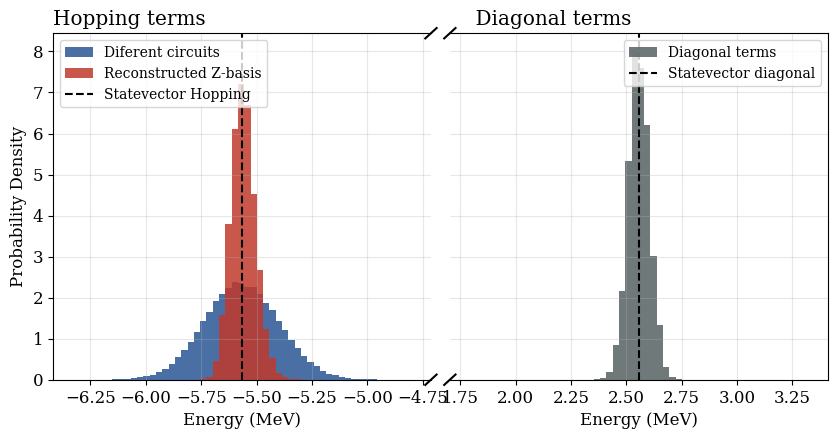

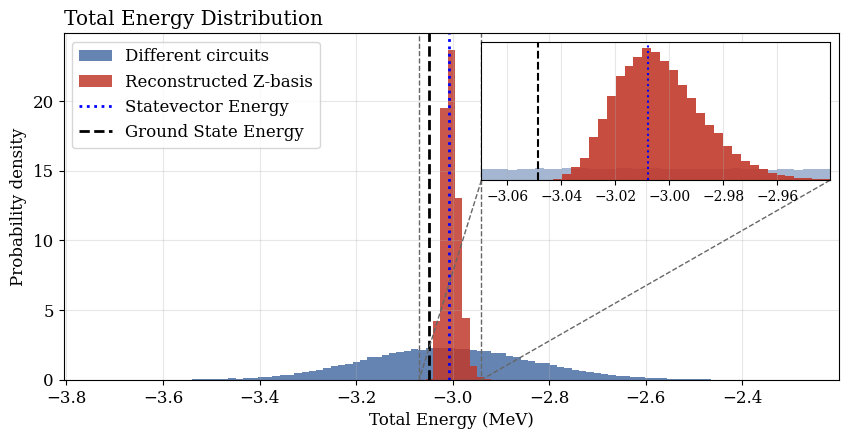

In [89]:
VALOR_CALCULADO = -3.0079065424758444
VALOR_GS_EXACTO = -3.04876320318616
VALOR_DIAG_REF  = 2.556971870608527
VALOR_HOP_REF   = -5.564878413084367
n_experiments = 50000

run_monte_carlo_analysis(composer.Qibo_measure_Energy, n_experiments, VALOR_CALCULADO, VALOR_GS_EXACTO, VALOR_DIAG_REF, VALOR_HOP_REF)

In [90]:
import numpy as np
from tqdm import tqdm
import contextlib


list_shots = [100, 250, 500, 1000, 2500]


medias_fixed = []
desviaciones_fixed = []

medias_sep_fixed = []
desviaciones_sep_fixed = []



for shots in list_shots:
    composer.nshots = shots
    
    energies = []
    energies_sep = []

    
    print(f'---------------- {shots} Shots ----------------')
    
    
    for _ in tqdm(range(1000), leave=False, desc=f"Simulando {shots}"):
       
        with contextlib.redirect_stdout(None): 
            Et_shots, E_diag, E_hop, ansatz = composer.Qibo_measure_Energy()
            
        energies.append(Et_shots)
        energies_sep.append(E_diag+E_hop)
        
   
    print(min(energies))
    p16, med, p84 = np.percentile(energies, [15.87, 50, 84.13])
    medias_fixed.append(np.median(energies))
    desviaciones_fixed.append([med - p16, p84 - med]) 
    mean= np.mean(energies_sep)
    std=np.std(energies_sep)
    medias_sep_fixed.append(mean)
    desviaciones_sep_fixed.append(std) 
    
    print(f"E_median: {med:.5f}  (-{med-p16:.4f} / +{p84-med:.4f})")
    print(f"E_mean_sep: {mean:.5f}  (+-{std})")


print("\n--- RESULTADOS: MEDIANAS ---")
print("Total:", medias_fixed)

print("\n--- RESULTADOS: ERRORES ASIMÉTRICOS [[down, up], ...] ---")
print("Total Err:", desviaciones_fixed)


---------------- 100 Shots ----------------


-3.0485866996430326
E_median: -2.97786  (-0.0486 / +0.0752)
E_mean_sep: -3.04090  (+-0.537286260115939)
---------------- 250 Shots ----------------


-3.048667932687909
E_median: -2.99534  (-0.0291 / +0.0391)
E_mean_sep: -3.00545  (+-0.33828448685898665)
---------------- 500 Shots ----------------


-3.045735240553351
E_median: -3.00124  (-0.0222 / +0.0261)
E_mean_sep: -3.02134  (+-0.24620057618612864)
---------------- 1000 Shots ----------------


-3.039256743566092
E_median: -3.00414  (-0.0155 / +0.0167)
E_mean_sep: -3.00418  (+-0.17074925988246153)
---------------- 2500 Shots ----------------


-3.0361991503159063
E_median: -3.00667  (-0.0094 / +0.0102)
E_mean_sep: -3.00727  (+-0.1102077012251643)

--- RESULTADOS: MEDIANAS ---
Total: [np.float64(-2.9778575741505104), np.float64(-2.9953369751828545), np.float64(-3.0012392380373845), np.float64(-3.004141014611657), np.float64(-3.006669262977195)]

--- RESULTADOS: ERRORES ASIMÉTRICOS [[down, up], ...] ---
Total Err: [[np.float64(0.04855813853384472), np.float64(0.07517739018126379)], [np.float64(0.029138811682490662), np.float64(0.03907299664531649)], [np.float64(0.02216306714422922), np.float64(0.026143419167918847)], [np.float64(0.015453533484735882), np.float64(0.016650890121245876)], [np.float64(0.009430670796791052), np.float64(0.010202907586522869)]]


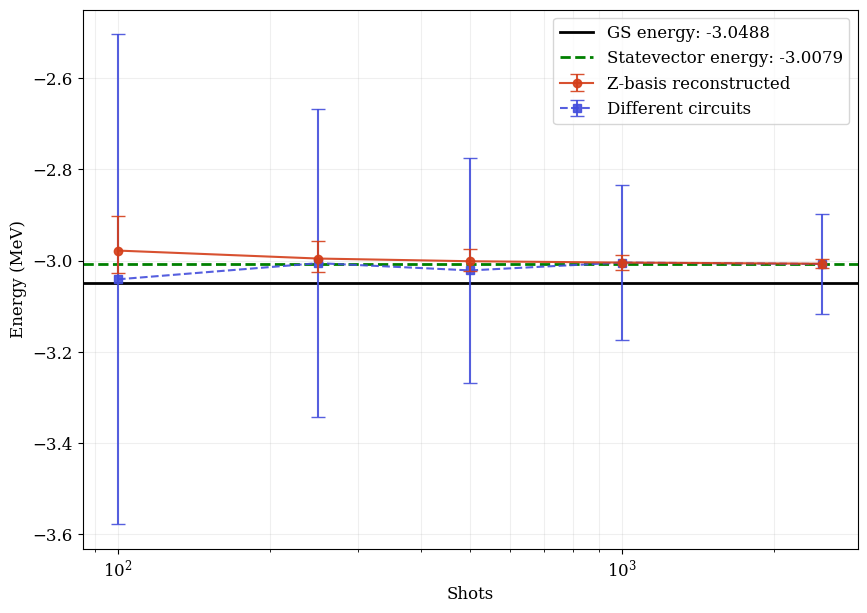

In [91]:
import matplotlib.pyplot as plt
import numpy as np

E_FCI = -3.0487979284658944 

E_Ansatz = -3.0079065424758444

y_err_asym = np.array(desviaciones_fixed).T 

plt.figure(figsize=(10, 7))


lower_bound_plot = min(np.min(medias_fixed), E_FCI ) 


plt.axhline(E_FCI, color='black', linestyle='-', linewidth=2, label=f'GS energy: {E_FCI:.4f}')


plt.axhline(E_Ansatz, color='green', linestyle='--', linewidth=2, label=f'Statevector energy: {E_Ansatz:.4f}')


plt.errorbar(list_shots, medias_fixed, yerr=y_err_asym, 
             fmt='-o',              
             linewidth=1.5,         
             markersize=6,          
             capsize=5,             
             color='#D43E19',      
             ecolor='#D43E19',     
             alpha=0.9,             
             label='Z-basis reconstructed', 
             zorder=10)


plt.errorbar(list_shots, medias_sep_fixed, yerr=desviaciones_sep_fixed, 
             fmt='--s',            
             linewidth=1.5,
             markersize=6,
             capsize=5,
             color='#434EDC',        
             ecolor='#434EDC',
             alpha=0.9,
             label='Different circuits', 
             zorder=9)

plt.xscale('log') 
plt.xlabel("Shots", fontsize=12)
plt.ylabel("Energy (MeV)", fontsize=12)
plt.legend(loc='upper right') 
plt.grid(True, which="both", ls="-", alpha=0.2)




plt.show()

### $^6\mathrm{Be}$: shot-count convergence sweep

In [92]:
list_shots=[1000, 3000, 5000, 10000]

desviaciones_fixed=[]
medias_fixed=[]

desviaciones_fixed_diag=[]
medias_fixed_diag=[]

desviaciones_fixed_hop=[]
medias_fixed_hop=[]

for shots in list_shots:
    composer.nshots = shots
    energies=[]
    e_diags=[]
    e_hops=[]
    print('----------------',shots,'----------------')
    for _ in tqdm(range(1000), leave=False, desc="Repeticiones"):
        with contextlib.redirect_stdout(f):
            Et_shots, E_diag, E_hop, ansatz = composer.Qibo_measure_Energy()
        energies.append(Et_shots)
        e_diags.append(E_diag)
        e_hops.append(E_hop)
        
    desviaciones_fixed.append(np.std(energies))
    medias_fixed.append(np.mean(energies))
    
    desviaciones_fixed_diag.append(np.std(e_diags))
    medias_fixed_diag.append(np.mean(e_diags))
    
    desviaciones_fixed_hop.append(np.std(e_hops))
    medias_fixed_hop.append(np.mean(e_hops))
    
    print('DONE')
    
print(medias_fixed)  
print(desviaciones_fixed)

print(medias_fixed_diag)
print(desviaciones_fixed_diag)

print(medias_fixed_hop)
print(desviaciones_fixed_hop)  

---------------- 1000 ----------------


DONE
---------------- 3000 ----------------


DONE
---------------- 5000 ----------------


DONE
---------------- 10000 ----------------


DONE
[np.float64(-3.0033495370012497), np.float64(-3.0065652095245428), np.float64(-3.0070452635383407), np.float64(-3.007660934442582)]
[np.float64(0.016084162010135215), np.float64(0.009117995687634295), np.float64(0.0070303503928728075), np.float64(0.004958374973232395)]
[np.float64(2.5569293284), np.float64(2.557947154933333), np.float64(2.55655377028), np.float64(2.55637526426)]
[np.float64(0.049071775080675395), np.float64(0.02787144419342819), np.float64(0.020768454606879864), np.float64(0.01621254186500851)]
[np.float64(-5.558298380836293), np.float64(-5.564149427352289), np.float64(-5.564579240113126), np.float64(-5.564216501382969)]
[np.float64(0.1653890759208147), np.float64(0.09602713009064391), np.float64(0.07464115171237069), np.float64(0.05250811372450592)]


In [93]:
nshots=[1000, 3000, 5000, 10000]
results={}
k=0
fallos = 0
with open("Convergence_data/Be6_QP_ADAPT_2_layer.dat", "w") as file:
    file.write("shots theta1_mean theta1_std theta2_mean theta2_std energy_mean energy_std energy_mean_fixed energy_std_fixed\n")
    
    for shots in nshots:
        
        fixed_E=medias_fixed[k]
        fiexd_std=desviaciones_fixed[k]
        thetas_1=[]
        thetas_2=[]
        energias=[]
        print('--------------', shots, ' shots --------------')
        for _ in tqdm(range(100), leave=False, desc="Repeticiones"):
            with contextlib.redirect_stdout(f):       
                data_mix, nucleo = Quantum_ADAPT_minimization(nuc, ref_state = ref_state, shell='p', max_layers=2, threshold=1e-2, exact=False, nshots=shots, encoding='HCB')
                if len(data_mix['parameters'])==2:
                    thetas_1.append(data_mix['parameters'][0])
                    thetas_2.append(data_mix['parameters'][1])
                    energias.append(data_mix['Energy'])
                else:
                    fallos += 1
            
        print('DONE')
        results[shots] = {'theta_1': [np.mean(thetas_1), np.std(thetas_1)], 'theta_2':[np.mean(thetas_2), np.std(thetas_2)],  'energy':[np.mean(energias), np.std(energias)]}
        
        media_t1, std_t1 = results[shots]['theta_1']
        media_t2, std_t2 = results[shots]['theta_2']

        media_E, std_E = results[shots]['energy']
        
        
        file.write(f"{shots} {media_t1:.6f} {std_t1:.6f} {media_t2:.6f} {std_t2:.6f} {media_E:.6f} {std_E:.6f} {fixed_E:.6f} {fiexd_std:.6f}\n")
        
        k += 1
        print(fallos)


-------------- 1000  shots --------------


DONE
0
-------------- 3000  shots --------------


DONE
0
-------------- 5000  shots --------------


DONE
0
-------------- 10000  shots --------------


DONE
0


In [94]:
nshots=[1000, 3000, 5000, 10000]
results={}
k=0
data_fallo=[]

with open("Convergence_data/Be6_QP_Roto_2_layer.dat", "w") as file:
    file.write("shots theta1_mean theta1_std theta2_mean theta2_std energy_mean energy_std energy_mean_fixed energy_std_fixed\n")
    
    for shots in nshots:
        fallos = 0
        fixed_E=medias_fixed[k]
        fiexd_std=desviaciones_fixed[k]
        thetas_1=[]
        thetas_2=[]
        energias=[]
        print('--------------', shots, ' shots --------------')
        for _ in tqdm(range(100), leave=False, desc="Repeticiones"):
            with contextlib.redirect_stdout(f):       
                data_mix, nucleo = Quantum_GGF_minimization(nuc, ref_state = ref_state, shell='p', max_layers=2, threshold=1e-2, exact=False, nshots=shots, encoding='HCB')
                if len(data_mix['parameters'])==2:
                    thetas_1.append(data_mix['parameters'][0])
                    thetas_2.append(data_mix['parameters'][1])
                    energias.append(data_mix['Energy'])
                else:
                    data_fallo.append(data_mix)
                    fallos += 1
            
        print('DONE')
        results[shots] = {'theta_1': [np.mean(thetas_1), np.std(thetas_1)], 'theta_2':[np.mean(thetas_2), np.std(thetas_2)],  'energy':[np.mean(energias), np.std(energias)]}
        
        media_t1, std_t1 = results[shots]['theta_1']
        media_t2, std_t2 = results[shots]['theta_2']

        media_E, std_E = results[shots]['energy']
        
        
        file.write(f"{shots} {media_t1:.6f} {std_t1:.6f} {media_t2:.6f} {std_t2:.6f} {media_E:.6f} {std_E:.6f} {fixed_E:.6f} {fiexd_std:.6f}\n")
        
        k += 1
        print(fallos)



-------------- 1000  shots --------------


DONE
0
-------------- 3000  shots --------------


DONE
0
-------------- 5000  shots --------------


DONE
0
-------------- 10000  shots --------------


DONE
0


In [95]:
nshots=[1000, 3000, 5000, 10000]
results={}
k=0
fallos = 0
with open("Convergence_data/Be6_QP_Roto_ADAPT_2_layer.dat", "w") as file:
    file.write("shots theta1_mean theta1_std theta2_mean theta2_std energy_mean energy_std energy_mean_fixed energy_std_fixed\n")
    
    for shots in nshots:
        
        fixed_E=medias_fixed[k]
        fiexd_std=desviaciones_fixed[k]
        thetas_1=[]
        thetas_2=[]
        energias=[]
        print('--------------', shots, ' shots --------------')
        for _ in tqdm(range(100), leave=False, desc="Repeticiones"):
            with contextlib.redirect_stdout(f):       
                data_mix, nucleo = Quantum_GGF_ADAPT_minimization(nuc, ref_state = ref_state, shell='p', max_layers=2, threshold=1e-2, exact=False, nshots=shots, encoding='HCB')
                if len(data_mix['parameters'])==2:
                    thetas_1.append(data_mix['parameters'][0])
                    thetas_2.append(data_mix['parameters'][1])
                    energias.append(data_mix['Energy'])
                else:
                    fallos =+ 1
            
        print('DONE')
        results[shots] = {'theta_1': [np.mean(thetas_1), np.std(thetas_1)], 'theta_2':[np.mean(thetas_2), np.std(thetas_2)],  'energy':[np.mean(energias), np.std(energias)]}
        
        media_t1, std_t1 = results[shots]['theta_1']
        media_t2, std_t2 = results[shots]['theta_2']

        media_E, std_E = results[shots]['energy']
        
        
        file.write(f"{shots} {media_t1:.6f} {std_t1:.6f} {media_t2:.6f} {std_t2:.6f} {media_E:.6f} {std_E:.6f} {fixed_E:.6f} {fiexd_std:.6f}\n")
        
        k += 1
        print(fallos)


-------------- 1000  shots --------------


DONE
0
-------------- 3000  shots --------------


DONE
0
-------------- 5000  shots --------------


DONE
0
-------------- 10000  shots --------------


DONE
0


## Convergence test sd shell

### $^{18}\mathrm{O}$

In [96]:
shell='sd'
nuc ='O18'
ref_state = 0

data, nucleus = GGF_minimization(nuc, ref_state = ref_state, shell=shell, max_layers=4, threshold=1e-5, encoding='HCB')


 --------------------------------------------------------------------------
                            ADAPT for  O18
 --------------------------------------------------------------------------

Initial Energy:  -9.3151
-9.814428280677735 [np.float64(2.5150229187950703)]

------------ LAYER 1 ------------
Operator: 0 1
Energy:  -9.814428280677735
Rel. Error:  0.1774553760293802
Theta: 2.5150229187950703
-10.481416088254 [np.float64(2.5150229187950703), np.float64(0.6067964744369881)]

------------ LAYER 2 ------------
Operator: 0 3
Energy:  -10.481416088254
Rel. Error:  0.12155530526765036
Theta: 0.6067964744369881
-11.16995019382875 [np.float64(2.5150229187950703), np.float64(0.6067964744369881), np.float64(0.7932650140910538)]

------------ LAYER 3 ------------
Operator: 0 2
Energy:  -11.16995019382875
Rel. Error:  0.0638494450010939
Theta: 0.7932650140910538
-11.531373851981947 [np.float64(2.5150229187950703), np.float64(0.6067964744369881), np.float64(0.7932650140910538), np.float

In [97]:
thetas = data['parameters'].copy()


used_operators = data['used_operators'] 

composer = Circuits_Composer(nucleus='O18',
                              shell='sd',
                              ref_state=0,
                              parameters=thetas,
                              operators_used=used_operators,
                              exact=False,
                              nshots=1000, encoding='HCB')
 
Et_shots = composer.Qibo_measure_Energy()
print(*Et_shots[:-1])

-11.514468765657531 -8.607785799999997 -2.8273612623544393


Simulando 10000 experimentos...


100%|██████████| 10000/10000 [02:32<00:00, 65.64it/s]


STD for tootal energy 0.19314909777042055
STD for tootal energy rec 0.011368168633361642
reduccion de: 16.990344179412922


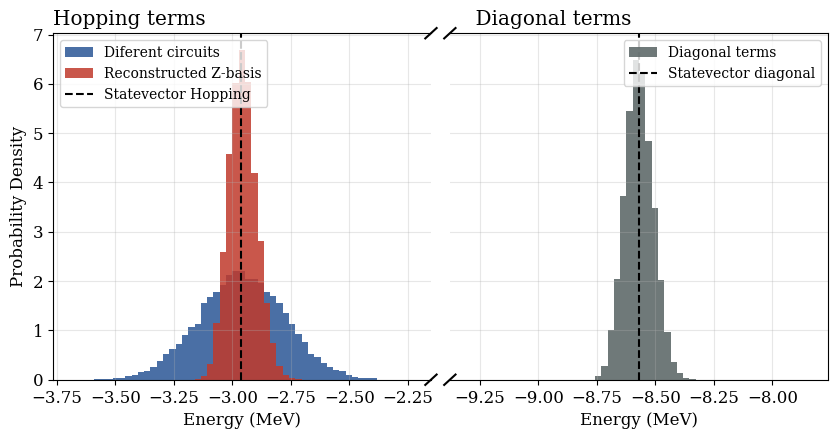

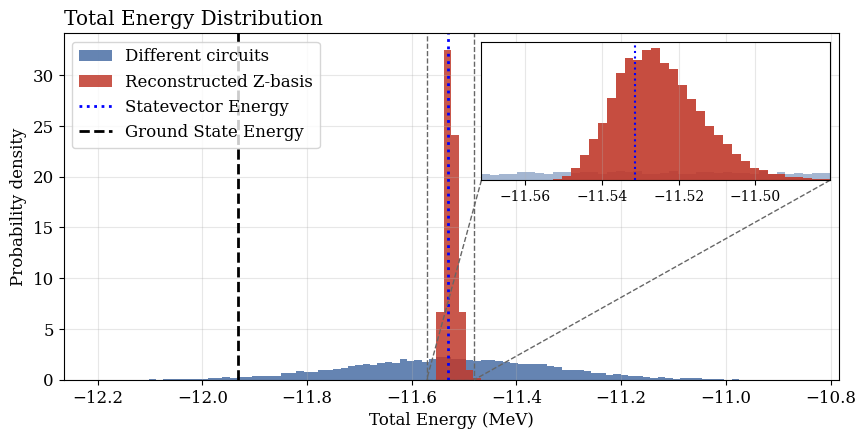

In [98]:
VALOR_CALCULADO = -11.53137385198194
VALOR_GS_EXACTO = -11.931771136330243
VALOR_DIAG_REF  = -8.570371432032788
VALOR_HOP_REF   = -2.9610024199491494
n_experiments = 10000

run_monte_carlo_analysis(composer.Qibo_measure_Energy, n_experiments, VALOR_CALCULADO, VALOR_GS_EXACTO, VALOR_DIAG_REF, VALOR_HOP_REF)

### $^{20}\mathrm{O}$

In [99]:
shell='sd'
nuc ='O20'
ref_state = 0

data, nucleus = GGF_minimization(nuc, ref_state = ref_state, shell=shell, max_layers=6, threshold=1e-2, encoding='HCB')

 --------------------------------------------------------------------------
                            ADAPT for  O20
 --------------------------------------------------------------------------

Initial Energy:  -20.00019767937434
-20.707247259680926 [np.float64(2.4378822297515583)]

------------ LAYER 1 ------------
Operator: 1 2
Energy:  -20.707247259680926
Rel. Error:  0.10536946289304927
Theta: 2.4378822297515583
-21.20960771472055 [np.float64(2.4378822297515583), np.float64(0.7756212402374645)]

------------ LAYER 2 ------------
Operator: 0 2
Energy:  -21.20960771472055
Rel. Error:  0.08366561215531886
Theta: 0.7756212402374645
-21.73184799528053 [np.float64(2.4378822297515583), np.float64(0.7756212402374645), np.float64(0.4311569092641575)]

------------ LAYER 3 ------------
Operator: 0 3
Energy:  -21.73184799528053
Rel. Error:  0.06110287859459273
Theta: 0.4311569092641575
-22.1084105961466 [np.float64(2.4378822297515583), np.float64(0.7756212402374645), np.float64(0.4311569092

In [100]:
thetas = data['parameters'].copy()

used_operators = data['used_operators'] 

composer = Circuits_Composer(nucleus='O20',
                              shell='sd',
                              ref_state=0,
                              parameters=thetas,
                              operators_used=used_operators,
                              exact=False,
                              nshots=1000, encoding='HCB')
 
Et_shots = composer.Qibo_measure_Energy()
print(*Et_shots[:-1])


-22.660215281640816 -18.655532304568 -4.004682977072816


Simulando 10000 experimentos...


100%|██████████| 10000/10000 [17:05<00:00,  9.75it/s]


STD for tootal energy 0.0549997344156663
STD for tootal energy rec 0.0549997344156663
reduccion de: 1.0


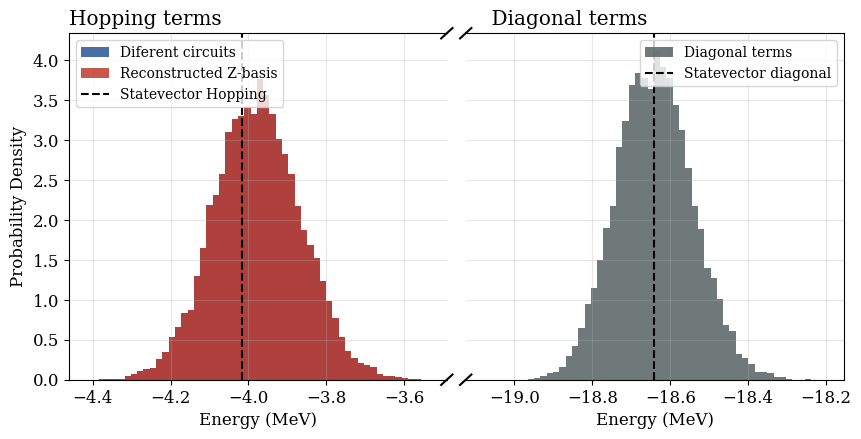

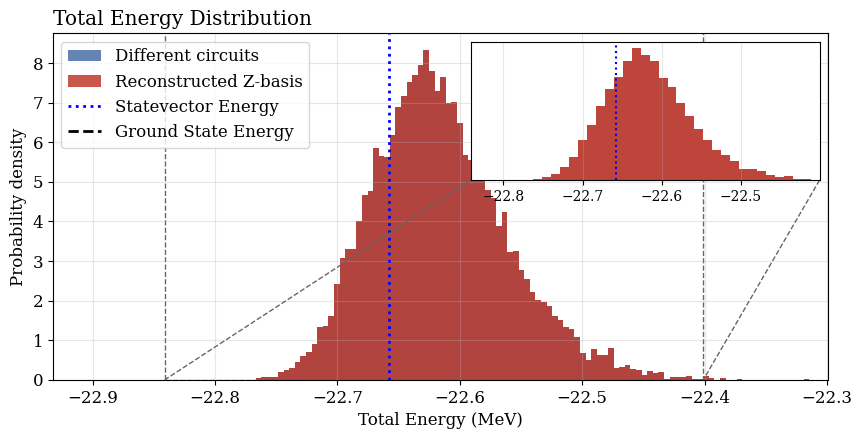

In [101]:
VALOR_CALCULADO = -22.657579315781554
VALOR_GS_EXACTO = -23.13909950003768
VALOR_DIAG_REF  = -18.641269312389323
VALOR_HOP_REF   = -4.016310003392225
n_experiments = 10000

run_monte_carlo_analysis(composer.Qibo_measure_Energy_complex, n_experiments, VALOR_CALCULADO, VALOR_GS_EXACTO, VALOR_DIAG_REF, VALOR_HOP_REF)

In [102]:
import numpy as np
from tqdm import tqdm
import contextlib

list_shots = [500, 1000, 2500, 5000, 10000]


medias_fixed = []
desviaciones_fixed = []

medias_sep_fixed = []
desviaciones_sep_fixed = []



for shots in list_shots:
    composer.nshots = shots
    
    energies = []
    energies_sep = []

    
    print(f'---------------- {shots} Shots ----------------')
    
    
    for _ in tqdm(range(2000), leave=False, desc=f"Simulando {shots}"):
        with contextlib.redirect_stdout(None): 
            Et_shots, E_diag, E_hop, ansatz = composer.Qibo_measure_Energy()
            
        energies.append(Et_shots)
        energies_sep.append(E_diag+E_hop)
        
   
    print(min(energies))
    p16, med, p84 = np.percentile(energies, [15.87, 50, 84.13])
    medias_fixed.append(np.mean(energies))
    desviaciones_fixed.append([med - p16, p84 - med]) 
    mean= np.mean(energies_sep)
    std=np.std(energies_sep)
    medias_sep_fixed.append(mean)
    desviaciones_sep_fixed.append(std) 
    
    
    print(f"E_median: {med:.5f}  (-{med-p16:.4f} / +{p84-med:.4f})")
    print(f"E_mean_sep: {mean:.5f}  (+-{std})")


print("\n--- RESULTADOS: MEDIANAS ---")
print("Total:", medias_fixed)

print("\n--- RESULTADOS: ERRORES ASIMÉTRICOS [[down, up], ...] ---")
print("Total Err:", desviaciones_fixed)


---------------- 500 Shots ----------------


-22.776148525267057
E_median: -22.56361  (-0.0658 / +0.0815)
E_mean_sep: -22.55710  (+-0.07559542639027252)
---------------- 1000 Shots ----------------


-22.765269651791534
E_median: -22.62214  (-0.0505 / +0.0580)
E_mean_sep: -22.61761  (+-0.054782015502343635)
---------------- 2500 Shots ----------------


-22.736411536141098
E_median: -22.65601  (-0.0361 / +0.0461)
E_mean_sep: -22.65152  (+-0.04022625720321556)
---------------- 5000 Shots ----------------


-22.737267227148372
E_median: -22.66182  (-0.0308 / +0.0354)
E_mean_sep: -22.65949  (+-0.03162946716897421)
---------------- 10000 Shots ----------------


-22.723279673269513
E_median: -22.65655  (-0.0280 / +0.0206)
E_mean_sep: -22.65859  (+-0.02346020703411553)

--- RESULTADOS: MEDIANAS ---
Total: [np.float64(-22.557103484459933), np.float64(-22.61761082987552), np.float64(-22.651524850217857), np.float64(-22.659493191621035), np.float64(-22.658585050336637)]

--- RESULTADOS: ERRORES ASIMÉTRICOS [[down, up], ...] ---
Total Err: [[np.float64(0.06580265147185571), np.float64(0.08149421676520419)], [np.float64(0.050502709390709555), np.float64(0.05802887192463757)], [np.float64(0.03606630981717629), np.float64(0.04614029516295304)], [np.float64(0.03075356575769206), np.float64(0.03540464461597281)], [np.float64(0.028043954681365335), np.float64(0.020603020537460992)]]


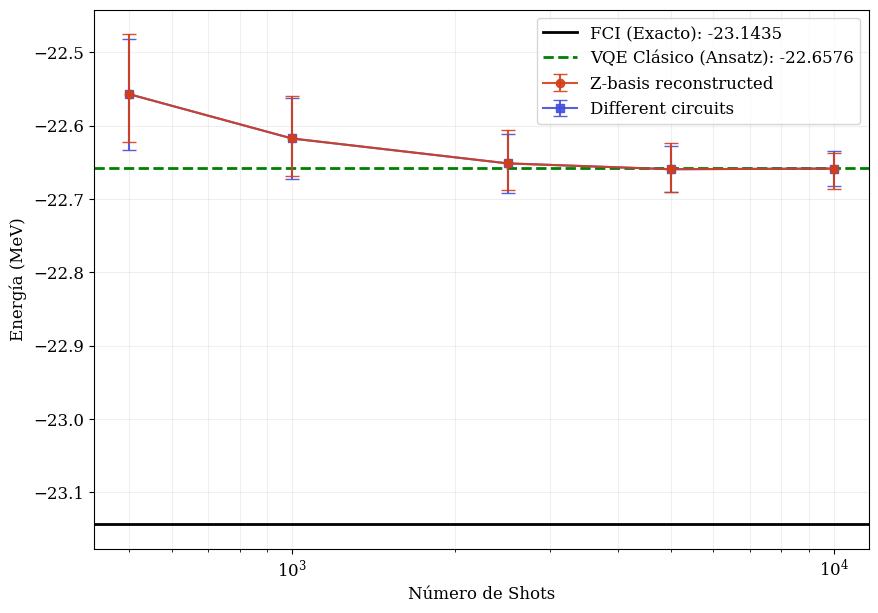

In [103]:
import matplotlib.pyplot as plt
import numpy as np

E_FCI = -23.14352598319472 
E_Ansatz = -22.657579315781554 

y_err_asym = np.array(desviaciones_fixed).T 

plt.figure(figsize=(10, 7))


lower_bound_plot = min(np.min(medias_fixed), E_FCI ) 


plt.axhline(E_FCI, color='black', linestyle='-', linewidth=2, label=f'FCI (Exacto): {E_FCI:.4f}')


plt.axhline(E_Ansatz, color='green', linestyle='--', linewidth=2, label=f'VQE Clásico (Ansatz): {E_Ansatz:.4f}')


plt.errorbar(list_shots, medias_fixed, yerr=y_err_asym, 
             fmt='-o',              
             linewidth=1.5,         
             markersize=6,          
             capsize=5,             
             color='#D43E19',      
             ecolor='#D43E19',     
             alpha=0.9,             
             label='Z-basis reconstructed', 
             zorder=10)


plt.errorbar(list_shots, medias_sep_fixed, yerr=desviaciones_sep_fixed, 
             fmt='-s',              
             linewidth=1.5,
             markersize=6,
             capsize=5,
             color='#434EDC',        
             ecolor='#434EDC',
             alpha=0.9,
             label='Different circuits', 
             zorder=9)

plt.xscale('log') 
plt.xlabel("Número de Shots", fontsize=12)
plt.ylabel("Energía (MeV)", fontsize=12)
plt.legend(loc='upper right') 
plt.grid(True, which="both", ls="-", alpha=0.2)


plt.show()